In [2]:
from jax import numpy as jnp
from jax import random
key = random.PRNGKey(0)
from math import log
from matplotlib import pyplot as plt
import policy as pol
from tqdm import tqdm

# Bandit loop
We consider an agent interacting with a stochastic bandit, and we repeat the experience for a certain random of trials. The repetition process is vectorized so we avoid a for loop: we run the different trials in parallel.

## Reward generation at each round
Either we call the random generation routine, or we access a predefined table corresponding to the reward table model. This latter can reduce execution time at the price of memory allocation.


In [3]:
n_repetitions= 1000
horizon = 10000
true_means = jnp.array([0.9, 0.1])
n_arms = len(true_means)

reward_tensor = random.bernoulli(key, true_means, (horizon, n_repetitions, n_arms)).astype('int8')
#reward_tensor = random.normal(loc= true_means, size= (horizon, n_repetitions, n_arms))
actions = jnp.empty((horizon, n_repetitions),dtype= 'int8')
rewards = jnp.empty((horizon, n_repetitions), dtype= 'float32')

#initialization: pull each arm once
for t in range(n_arms):
    actions[t] = t
    #rewards[k] = random.binomial(1, true_means[actions[k]])
    rewards[t] = reward_tensor[t,jnp.arange(n_repetitions),actions[t]]

# cumul_rewards = rewards[:n_arms,:].copy()
# n_pulls = jnp.ones((n_arms, n_repetitions), dtype= "int")


# # run n_repetitions experiments in a vectorized way
# policy_args = (1,1)
# for t in tqdm(range(n_arms, horizon)):
    
#     # play action / pull arm
#     actions[t] = pol.ucb1(cumul_rewards, n_pulls, horizon**2)
  
#     # collect reward from pulled arm
#     rewards[t] = reward_tensor[t,np.arange(n_repetitions),actions[t]]

#     # update the empirical mean of the played arm
#     act_rep_tuple =  (actions[t], range(n_repetitions)) 
#     cumul_rewards[act_rep_tuple] += rewards[t]
#     n_pulls[act_rep_tuple] += 1

TypeError: '<class 'jaxlib.xla_extension.DeviceArray'>' object does not support item assignment. JAX arrays are immutable. Instead of ``x[idx] = y``, use ``x = x.at[idx].set(y)`` or another .at[] method: https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.ndarray.at.html

# Plotting the regret
Having stored the rewards, there are two ways to estimate the expected regret:
* Taking the sum of the realized regrets (although in our case, the oracle's reward is already averaged), and then taking the average over experiments.
  $$R_{\text{realized}}(T) = \sum_{t=1}^T (r_{a^\star} - r_{a_t})$$
  where $r_{a_t} \sim \mathcal P_{a_t}$.
  
* Semi-realized regret, where a expecatation is taken for the oracle:
  $$R_{\text{realized}}(T) = \sum_{t=1}^T (\mu_{a^\star} - r_{a_t})$$
* Taking the sum of the expectation of regret conditional on the taken action, since we know the true mean
$$R_{\text{pseudo}}(T) = \sum_{t=1}^T (\mu_{a^\star} - \mu_{a_t}),$$
followed by an averaging over all trials. This way, we have a much smoother regret with a moderate number of trials.


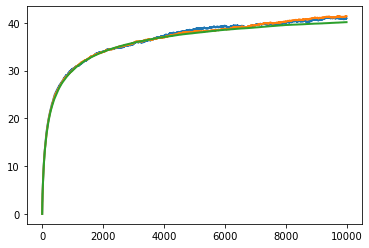

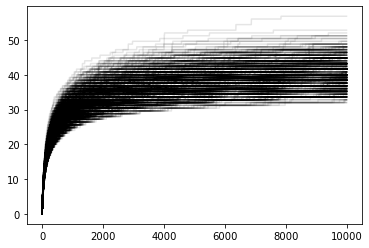

In [8]:
agent_cumul_reward = jnp.cumsum(rewards, axis= 0)
expected_rewards = true_means[actions]
cumul_expected_reward = jnp.cumsum(expected_rewards, axis= 0)
oracle_expec_cumul_reward = (np.arange(horizon)+1)*true_means.max()
oracle_realized_cumul_reward = jnp.cumsum(random.binomial(1,true_means.max(), (horizon, n_repetitions)),
axis= 0)


plt.figure()
horizon_range = jnp.arange(horizon)+1
realized_regret = oracle_realized_cumul_reward - agent_cumul_reward
semi_realized_regret = oracle_expec_cumul_reward[:,None] - agent_cumul_reward
pseudo_regret = oracle_expec_cumul_reward[:,None] - cumul_expected_reward
plt.plot(horizon_range, realized_regret.mean(axis= 1), linewidth= 2)
plt.plot(horizon_range, semi_realized_regret.mean(axis= 1), linewidth= 2)
plt.plot(horizon_range, pseudo_regret.mean(axis= 1), linewidth= 2)
plt.savefig("regret.png", format= "png")# %%

plt.figure()
#plt.plot(horizon_range, realized_regret, 'b', alpha= 0.1)
plt.plot(horizon_range, pseudo_regret, 'k', alpha= 0.1)
plt.savefig("regret_realizations.png", format= "png")# %%


# Pull trajectory representation
We represent the trajectory of arms:
* As a walk in a space spanned by arms, with mean as velocity. This is only available for 2 arms, Maybe for more than 2, one can try a dim reduction approach,

In [1]:
assert n_arms == 2, "cannot represent more than two arms !"
actions_x, actions_y = (true_means[actions==1], true_means[actions==0])
plt.plot(np.cumsum(actions_x, axis= 0), jnp.cumsum(actions_y, axis= 0),color= 'k', alpha= 0.3);


NameError: name 'n_arms' is not defined

In [7]:
actions.shape

(10000, 1000)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])